**Análisis de Base de Datos EEG Motor Movement/Imagery**
---

Juan Pablo Florez
Valentina Díaz Patiño

**Base de Datos General**

La base de datos **eegmmidb** contiene registros de EEG de 109 sujetos realizando tareas
de movimiento real e imaginario. Cada sujeto tiene 14 runs registrados con 64 canales
EEG según el sistema internacional 10-10.

Estructura de los 14 runs por sujeto:

| Secuencias | Descripción | Eventos |
|-----|-------------|---------|
| 1 | Baseline ojos abiertos | T0 |
| 2 | Baseline ojos cerrados | TO |
| 3, 7, 11 | Task 1: Movimiento **real** izquierda/derecha | T1=izq real, T2=der real |
| 4, 8, 12 | Task 2: Movimiento **imaginario** izquierda/derecha | T1=izq imaginaria, T2=der imaginaria |
| 5, 9, 13 | Task 3: Movimiento **real** ambos puños/pies | T1=puños, T2=pies |Movimiento **imaginario** ambos puños/pies | T1=puños imaginarios, T2=pies imaginarios |

Con el fin de identificar mediante análisis estadístico qué canales de EEG permiten diferenciar significativamente entre ambas intenciones motoras, se toman las siguientes condiciones:

| Parámetro | Valor |
|-----------|-------|
| Sujetos | 10 (sub-001 a sub-010) |
| Secuencias | 4, 8 y 12 (Task 2: mov. imaginario) |
| Evento T1 | mov. imaginario mano izquierda |
| Evento T2 | mov. imaginario mano derecha |
| Canales | 64 (se mantienen) |

Se seleccionan únicamente los runs 4, 8 y 12 porque corresponden a **Task 2**,
que es la tarea **motora imaginaria** de mano izquierda y derecha.

***1. Cálculo del RMS***

-Seleccione una población de 10 sujetos, discriminando entre los dos grupos de estudio:Grupo Mano Izquierda y Grupo Mano Derecha

-Implemente una función que reciba una señal de múltiples canales y épocas (segmentada por clase) y calcule el valor RMS.

La función debe primero calcular el RMS para cada época de cada canal de forma
individual sobre el eje del tiempo
Posteriormente, la función debe promediar estos valores a través de todas las épocas para
obtener un valor representativo del sujeto por cada canal.

In [28]:
!pip install mne


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
import numpy as np
import mne
# from google.colab import drive

In [30]:
# drive.mount('/content/drive') # Para conectar Colab con Google Drive

DATA_PATH = '.' #Ruta base para acceder a archivos de sujetos

SUJETOS    = list(range(1, 11))  # Sujetos 1 al 10
RUNS_TASK2 = [4, 8, 12]          # Runs de mov. imaginario (Task 2)
TMIN, TMAX = 0.0, 4.0            # Ventana temporal de cada época en segundos

# Exploración de los datos
ruta_ejemplo = f'{DATA_PATH}/1/sub-001_task-motion_run-4_eeg.set'
raw_ejemplo  = mne.io.read_raw_eeglab(ruta_ejemplo, preload=True)

print(raw_ejemplo)              # Resumen: canales, duración, tamaño en memoria
print(raw_ejemplo.info)         # Metadatos: frecuencia de muestreo, filtros, canales
print(raw_ejemplo.ch_names)     # Nombres de los 64 canales
print(raw_ejemplo.annotations)  # Eventos anotados (T0, T1, T2) con sus tiempos



<RawEEGLAB | sub-001_task-motion_run-4_eeg.set, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>
<Info | 8 non-empty values
 bads: []
 ch_names: Fc5, Fc3, Fc1, Fcz, Fc2, Fc4, Fc6, C5, C3, C1, Cz, C2, C4, C6, ...
 chs: 64 EEG
 custom_ref_applied: False
 dig: 67 items (3 Cardinal, 64 EEG)
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: unspecified
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
>
['Fc5', 'Fc3', 'Fc1', 'Fcz', 'Fc2', 'Fc4', 'Fc6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'Cp5', 'Cp3', 'Cp1', 'Cpz', 'Cp2', 'Cp4', 'Cp6', 'Fp1', 'Fpz', 'Fp2', 'Af7', 'Af3', 'Afz', 'Af4', 'Af8', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'Ft7', 'Ft8', 'T7', 'T8', 'T9', 'T10', 'Tp7', 'Tp8', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'Po7', 'Po3', 'Poz', 'Po4', 'Po8', 'O1', 'Oz', 'O2', 'Iz']
<Annotations | 30 segments: TASK2T0 (15), TASK2T1 (8), TASK2T2 (7)>


Se cargan los documentos de la manera:

In [31]:
# FUNCIÓN: cargar_epocas_sujeto
# Carga los runs 4, 8 y 12 de un sujeto (Task 2 - imaginaria),
# aplica filtro pasa banda mu/beta (8-30 Hz), concatena los
# runs y segmenta las épocas por clase:
#   T1 → mano izquierda imaginaria
#   T2 → mano derecha imaginaria
def cargar_epocas_sujeto(sujeto_id, data_path, runs, tmin, tmax):

   # Une múltiples registros (runs) en una sola señal continua para análisis conjunto
    registros_concat = mne.concatenate_raws([
        mne.io.read_raw_eeglab(
            f'{data_path}/{sujeto_id}/sub-{sujeto_id:03d}_task-motion_run-{run}_eeg.set',
            preload=True)
        for run in runs
    ])

    # Filtro pasa banda 8-30 Hz: aísla los ritmos mu (8-13 Hz) y beta (13-30 Hz)
    # Durante imaginería motora se observa ERD (desincronización) en estas bandas
    # sobre la corteza sensoriomotora, mejorando la discriminación entre T1 y T2 [1]
    # Referenciador Espacial CAR (Common Average Reference):
    # La máquina suele medir con respecto a una referencia física que puede contaminarse de ruido ambiente.
    # El método 'average' suma la estática global de los 64 nodos del gorro (Sistema 10-10) al mismo instante, extrae el ruido promedio
    # y lo descarta de todos los canales. Esto crea un "Gorro Virtual Perfectamente Aterrizado", aislando puros datos corticales.
    registros_concat.set_eeg_reference('average')
    registros_concat.filter(l_freq=8.0, h_freq=30.0,
                            method='fir', fir_window='hamming')

    # Convierte anotaciones de texto en eventos numéricos para ubicar temporalmente las tareas (T1, T2)
    # mapa_eventos → diccionario: {'TASK2T1': id, 'TASK2T2': id, 'TASK2T0': id}
    eventos, mapa_eventos = mne.events_from_annotations(registros_concat)

    # Filtra el mapa para obtener solo los IDs de T1 y T2, es decir, solo lo de mano izquiersa y solo mano derecha
    # Ejemplo → id_T1: {'TASK2T1': 1} | id_T2: {'TASK2T2': 2}
    id_T1 = {k: v for k, v in mapa_eventos.items() if 'T1' in k}
    id_T2 = {k: v for k, v in mapa_eventos.items() if 'T2' in k}

    print(f'sub-{sujeto_id:03d} — eventos encontrados: {mapa_eventos}')

    # Segmenta el registro continuo en ventanas de [tmin, tmax] segundos
    # alrededor de cada evento T1 y T2 → shape: (n_epocas, 64, n_tiempos)(Ej: 22 veces mueve la mano, con 64 electodos en 4s a 256 Hz da (22,64,256))
    # baseline=None: sin corrección | preload=True: datos cargados en memoria 
    # No requiere baseline porque ya los vamos a analizar entre 8-30 Hz
    epocas_T1 = mne.Epochs(registros_concat, eventos, event_id=id_T1,
                            tmin=tmin, tmax=tmax, baseline=None, preload=True)
    epocas_T2 = mne.Epochs(registros_concat, eventos, event_id=id_T2,
                            tmin=tmin, tmax=tmax, baseline=None, preload=True)

    return epocas_T1, epocas_T2

# FUNCIÓN: calcular_rms_sujeto
# Recibe un objeto mne.Epochs (n_epocas, n_canales, n_tiempos)
# y calcula un valor RMS representativo por canal:
#   Paso 1 → Convierte V → µV (×1e6): unidad estándar en EEG
#   Paso 2 → RMS por época por canal (sobre el eje del tiempo)
#   Paso 3 → Promedio del RMS sobre todas las épocas
# Retorna array (n_canales,) con el RMS promedio por canal en µV

def calcular_rms_sujeto(epocas):
    # Extrae los datos y convierte V → µV (MNE almacena en voltios)
    # shape: (n_epocas, n_canales, n_tiempos)
    data = epocas.get_data() * 1e6
    # RMS por época:
    # Para cada época (intento de la tarea) y cada canal, se toma la señal en el tiempo,
    # se eleva al cuadrado, se promedia y se saca la raíz.
    # Esto convierte la señal oscilante en un único valor que representa su "energía" o amplitud promedio.

    rms_por_epoca = np.sqrt(np.mean(data**2, axis=2))
    rms_por_epoca = np.sqrt(np.mean(data**2, axis=2))

    # Se promedian todas las épocas por canal para obtener su valor repreentativo
    rms_promedio = np.mean(rms_por_epoca, axis=0)

    return rms_promedio, epocas.ch_names
# Para los 10 sujetos
resultados_T1 = {}
resultados_T2 = {}

for sujeto_id in SUJETOS:
    print(f'\nProcesando sub-{sujeto_id:03d}...')
    try:
        # Carga y segmenta las épocas del sujeto para cada tarea 
        epocas_T1, epocas_T2 = cargar_epocas_sujeto(
            sujeto_id, DATA_PATH, RUNS_TASK2, TMIN, TMAX
        )
        # Calcula el RMS promedio por canal para cada condición
        rms_T1, canales = calcular_rms_sujeto(epocas_T1)
        rms_T2, _       = calcular_rms_sujeto(epocas_T2)
         # Guarda los resultados del sujeto en cada condición
        resultados_T1[sujeto_id] = rms_T1
        resultados_T2[sujeto_id] = rms_T2

        print(f'  T1: {len(epocas_T1)} épocas | T2: {len(epocas_T2)} épocas ✓')

    except Exception as e:
        print(f'  ERROR en sub-{sujeto_id:03d}: {e}')

print('\n Procesamiento completo para los 10 sujetos')
print(f'Canales: {canales}')


Procesando sub-001...
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 3 contiguous segments
Setting up band-pass filter from 8 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 265 samples (1.656 s)

Used Annotations descriptions: ['TASK2T0', 'TASK2T1', 'TASK2T2']
sub-001 — eventos encontrados: {'TASK2T0': 1, 'TASK2T1': 2, 'TASK2T2': 3}
Not setting metadata
23 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 23 events and 641 original

***Cabe resaltar que según el estudio los electrodos están ubicados de la siguiente manera***
Además, se han registrado que las áreas relazionadas a este movimiento son las sensiomotoras (entre la zona frontal central y parietal) y el lóbulo frontal [1].

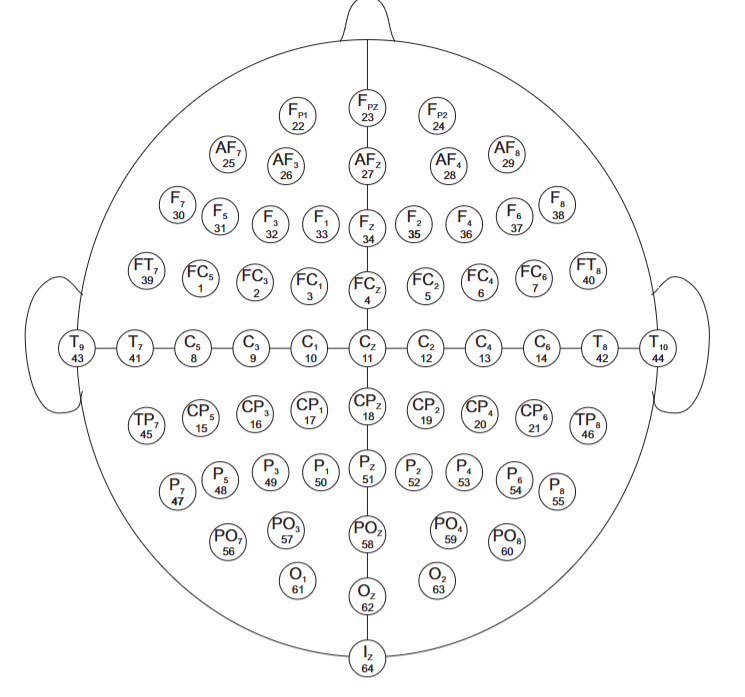

***Punto 2. Construcción de la Base de Datos Poblacional***:

Organice la información anterior en un DataFrame o dos, donde las columnas deben corresponder a los nombres de los canales (ej. C3, C4, Cz) y las filas deben corresponder a cada sujeto analizado (cada uno con los respectivos datos izquierdo y derecho), y cada
celda contendrá el valor de RMS promedio calculado en el punto anterior

Para construir la base de datos poblacional, se organizaron los valores RMS calculados en el punto anterior en dos DataFrames de pandas, uno por clase: Grupo Mano Izquierda (T1) y Grupo Mano Derecha (T2). En cada DataFrame, las filas corresponden a los 10 sujetos analizados y las columnas a los 64 canales EEG, de modo que cada celda contiene el RMS promedio representativo de ese sujeto en ese canal.
Es importante notar que en esta tabla ya no se distingue entre los runs 4, 8 y 12, puesto que estos tres runs corresponden a repeticiones de la misma tarea (Task 2). Al concatenarlos y promediar todas las épocas resultantes, se obtiene un único valor por canal por sujeto que es más robusto y representativo, ya que está basado en aproximadamente 63 épocas por sujeto (~21 épocas por run × 3 runs) en lugar de las épocas de un solo run.

***Frecuencias de ancho de banda encontradas***: El movimiento imaginario se asocia con cambios en las bandas de frecuencia mu (8–13 Hz) y beta (13–30 Hz) del EEG, localizadas principalmente en la corteza sensoriomotora. Durante estas tareas se observa una disminución de potencia en dichas bandas, conocida como desincronización relacionada con eventos (ERD), la cual indica activación cortical asociada a este tipo de movimiento [1]. Por esta razón, previo al cálculo del RMS se aplica un filtro pasa banda de 8–30 Hz sobre la señal cruda, con el fin de aislar las componentes espectrales que contienen información relevante sobre la imaginería motora y mejorar la detectabilidad de diferencias estadísticas entre los grupos T1 y T2.

In [32]:

# Se organizan los valores RMS promedio por canal de cada sujeto
# en dos DataFrames: uno por clase (T1: izquierda, T2: derecha)

import pandas as pd

# Construye el DataFrame para cada grupo
# Cada fila es un sujeto, cada columna un canal, cada celda el RMS promedio
df_T1 = pd.DataFrame(resultados_T1, index=canales).T 
df_T2 = pd.DataFrame(resultados_T2, index=canales).T  

# Renombra el índice para identificar cada fila como sujeto
df_T1.index = [f'sub-{i:03d}' for i in SUJETOS]
df_T2.index = [f'sub-{i:03d}' for i in SUJETOS]

pd.set_option('display.max_columns', 64)
pd.set_option('display.float_format', '{:.6f}'.format)

print(' Grupo Mano Izquierda (T1)')
display(df_T1)

print('\n Grupo Mano Derecha (T2)')
display(df_T2)

 Grupo Mano Izquierda (T1)


,Fc5,Fc3,Fc1,Fcz,Fc2,Fc4,Fc6,C5,C3,C1,Cz,C2,C4,C6,Cp5,Cp3,Cp1,Cpz,Cp2,Cp4,Cp6,Fp1,Fpz,Fp2,Af7,Af3,Afz,Af4,Af8,F7,F5,F3,F1,Fz,F2,F4,F6,F8,Ft7,Ft8,T7,T8,T9,T10,Tp7,Tp8,P7,P5,P3,P1,Pz,P2,P4,P6,P8,Po7,Po3,Poz,Po4,Po8,O1,Oz,O2,Iz
sub-001,10.847284,10.755389,10.839554,11.471762,10.258470,9.654847,10.675241,9.741853,9.170239,8.431312,9.258613,8.915378,8.507762,9.726951,10.449191,9.258991,8.461010,8.595632,8.373864,9.040691,9.486991,13.731158,12.009848,12.458917,13.959795,13.459984,11.153709,11.108457,12.835845,13.288045,13.825854,9.743703,11.817041,11.475262,10.569747,9.836469,11.636162,12.829857,11.096722,11.585962,11.333601,15.313241,12.462841,14.827490,11.350123,11.248701,13.391612,12.022239,11.260383,11.166461,10.369829,11.740985,11.766279,12.217142,12.932593,15.917404,14.717312,14.161628,15.821330,19.149518,19.554848,18.403951,20.720031,19.102901
sub-002,7.567722,7.293624,7.832438,8.757889,7.796848,7.118910,6.727119,7.469264,7.365725,7.760213,9.564850,7.114827,5.820670,6.188024,7.156049,7.942601,8.013327,9.189380,7.565132,6.395635,6.499059,7.919516,7.924401,7.607130,10.819887,7.868199,7.778813,7.477883,7.627187,8.635906,8.706761,8.164963,8.127575,8.201886,8.130683,8.015975,7.677036,7.606803,7.570242,7.611603,14.431790,9.581838,8.009652,9.083590,7.687812,7.231695,8.153738,8.646444,8.622215,9.137659,9.360198,9.158723,8.420345,8.555521,8.539530,10.597387,10.786672,14.080494,10.403335,11.546379,14.474959,11.450470,16.127652,11.447605
sub-003,12.640834,9.365395,9.162712,9.352067,9.082722,11.072568,11.024086,9.892796,8.596972,7.942450,8.400419,8.168581,8.933661,12.084139,9.649436,8.474735,8.025177,8.205712,8.466313,8.395904,9.081448,18.624114,17.126316,19.669280,18.710942,12.853555,10.031621,13.893855,14.164480,13.385421,11.449550,8.538704,8.133724,8.169264,9.105816,9.096816,11.435762,13.151388,14.972583,11.498363,14.480403,13.956788,14.335803,13.865609,12.465122,12.522375,12.576014,11.430875,9.947973,9.944398,10.052898,10.039760,10.519286,11.386587,12.312091,15.911853,13.481013,12.822322,13.563185,15.484850,16.025335,14.456521,14.601579,13.793649
sub-004,5.470637,4.194547,4.157825,3.947366,3.949366,4.350152,4.320028,4.581002,3.941240,3.779129,3.987678,3.626201,4.224876,5.117740,5.104115,3.624695,3.503066,3.657318,3.427703,4.811167,4.241154,5.517057,4.917725,6.226122,8.197074,10.165319,4.849674,5.159796,10.683220,7.925016,7.204927,5.752253,4.608481,3.584364,4.077321,3.981531,5.134170,6.652052,5.139432,39.895731,4.833135,5.054986,5.812401,5.835963,4.678837,5.817732,4.828865,3.849146,3.768760,3.842538,3.667119,4.426888,3.729141,4.270201,4.399122,4.766908,4.097275,4.303715,4.070152,4.667002,4.741362,4.583475,4.518807,4.648916
sub-005,14.873686,5.143580,4.792917,5.081028,6.214787,7.616244,8.719321,6.596720,4.092497,4.188997,4.508327,4.302702,4.765584,8.414043,16.224659,4.190588,4.271418,4.074201,4.182111,4.658545,11.118797,10.786966,6.468538,12.098979,16.140681,7.817055,5.385671,12.400660,16.846509,16.169050,14.623582,8.473162,5.470396,5.104630,5.801720,7.309589,12.833803,18.959831,10.737818,7.502440,12.204104,10.319015,9.534434,11.393528,15.612979,7.649354,8.756944,7.905836,4.860976,5.722102,5.060908,4.911720,5.013661,7.545466,9.043419,8.118188,6.399275,6.868686,5.841766,9.823772,6.842239,7.100394,6.240935,8.153769
sub-006,17.275088,7.547519,7.520876,6.083283,6.813773,6.646416,11.683897,8.305074,7.191290,5.954075,5.153006,5.260568,6.183803,6.025768,6.496523,5.310652,5.315214,4.953887,5.290741,6.012186,5.911689,24.655075,8.134275,10.083708,18.081189,17.760426,5.491368,13.068107,13.490720,8.250990,6.046159,5.985601,5.950217,6.034791,6.758828,6.731761,12.382116,17.196614,22.220685,5.889336,13.341185,5.853920,12.339795,8.832094,9.181800,5.854740,6.054166,6.021629,5.465133,5.424322,5.360301,5.683201,5.615514,5.649911,5.929730,6.289733,5.932851,5.942597,5.987882,6.009705,6.042056,6.601754,6.681895,7.202478
sub-007,11.259597,10.024013,9.249482,8.270464,8.487003,8.287258,9.476950,11.920606,9.487621,7.779395,7.685543,7.134224,7.048763,9.663511,10


 Grupo Mano Derecha (T2)


,Fc5,Fc3,Fc1,Fcz,Fc2,Fc4,Fc6,C5,C3,C1,Cz,C2,C4,C6,Cp5,Cp3,Cp1,Cpz,Cp2,Cp4,Cp6,Fp1,Fpz,Fp2,Af7,Af3,Afz,Af4,Af8,F7,F5,F3,F1,Fz,F2,F4,F6,F8,Ft7,Ft8,T7,T8,T9,T10,Tp7,Tp8,P7,P5,P3,P1,Pz,P2,P4,P6,P8,Po7,Po3,Poz,Po4,Po8,O1,Oz,O2,Iz
sub-001,10.208717,9.626868,9.901140,10.943812,10.199828,9.831950,10.584816,9.344267,8.181461,7.682823,8.618537,8.769451,8.663127,9.770832,9.867310,8.360430,7.790223,8.152852,8.141770,8.971718,9.418764,13.177775,11.740266,12.302055,12.948202,12.485357,10.766911,10.925872,13.098437,12.076727,12.780918,9.379021,11.000791,10.970601,10.304826,9.513149,11.747765,13.511739,10.415190,11.822727,11.092872,15.328282,12.324787,15.050987,11.300434,11.080082,12.848367,11.129990,10.286978,10.505559,10.100547,11.447054,11.336333,11.410454,12.066424,14.653911,13.542823,13.518430,14.733497,17.111684,17.011374,16.456722,18.776079,17.525853
sub-002,7.828598,7.444277,7.809326,8.854536,8.088596,7.443205,6.810971,7.787724,6.837199,7.305393,9.006691,7.063794,6.079386,6.465451,7.325242,7.016690,7.093642,8.687132,7.373661,7.177109,7.526017,7.690662,7.789965,7.564919,10.212751,7.646611,7.850252,7.579230,7.683999,8.354614,8.523261,8.040276,8.033629,8.277002,8.345933,8.233746,7.763067,7.606478,7.505052,7.281216,14.669485,9.178980,7.872730,8.881202,8.039259,7.680117,8.231169,8.420125,7.939504,8.563559,9.095386,9.212795,8.848695,9.504435,9.083562,10.415986,10.393893,14.327521,11.138055,12.527938,14.721255,12.185323,17.745818,12.183063
sub-003,12.708191,9.305167,9.199384,9.493037,9.168686,11.409051,11.378522,9.977947,8.595060,8.084323,8.562466,8.095614,9.159704,12.412931,9.991466,9.474439,8.611991,8.583191,8.548077,8.444212,8.997361,19.270733,17.900612,19.915621,19.253823,13.767601,11.107066,14.780237,15.084517,13.670380,11.966612,9.513024,9.037445,8.953390,10.015296,10.001210,12.437164,14.212477,14.935579,12.233897,14.067475,14.317172,13.954352,14.085290,12.264009,12.153877,14.109615,13.323046,11.796069,10.979137,10.624922,10.363668,10.511178,11.299630,12.288112,19.156713,16.321211,13.650489,13.684948,15.663545,19.285537,15.571239,15.509653,14.358153
sub-004,5.130187,3.925725,4.058695,4.027379,4.034113,4.533922,4.503844,4.323632,3.630126,3.731460,4.080562,3.869800,4.562922,5.155895,4.793073,3.393666,3.527604,3.852840,3.710696,4.957549,4.252451,5.404244,4.958239,6.560768,7.716777,9.948953,4.879796,5.546479,11.245286,6.936808,6.764554,5.522015,4.483665,3.511894,4.286678,4.178123,5.445889,7.195027,4.790764,37.981868,4.606584,4.982350,5.547140,5.798396,4.345740,5.677150,4.674903,3.717588,3.644776,3.843516,3.765567,4.485805,3.867379,4.266020,4.315065,4.821293,4.114257,4.367104,4.242296,4.753943,4.756581,4.707506,4.684407,4.743473
sub-005,15.242157,5.114283,4.849747,5.009855,6.251765,7.766146,8.612532,6.630116,4.293868,4.730038,4.407404,4.308685,4.790598,8.295767,16.326017,4.381636,4.403711,4.106224,4.125596,4.625112,11.748535,10.201383,6.269457,12.025030,15.535383,7.526372,5.249227,12.327913,17.404752,15.354785,14.718225,8.282601,5.366421,4.913341,5.743699,7.321704,13.547056,19.362589,10.317211,7.425623,11.667000,10.198155,9.226981,11.456192,15.744565,7.708519,8.780895,7.806188,4.844922,5.630198,4.882978,4.774764,5.047147,7.619456,9.092709,8.073349,6.233496,6.372817,5.906288,9.823263,6.717734,6.924377,6.134506,8.077635
sub-006,17.231706,7.397949,7.380910,6.016239,7.146065,6.966793,12.691359,8.213261,7.224340,5.999008,5.197164,5.352904,6.315971,6.647921,6.634221,5.511283,5.523365,4.957309,5.164399,5.883841,5.875977,25.142301,8.152716,10.485549,18.130001,17.776810,5.447814,14.188287,14.671509,7.986075,5.700142,5.673706,5.648716,5.720814,7.179712,7.139006,12.648698,18.919447,22.361703,6.483212,12.834629,6.435928,12.314565,9.216329,8.864118,6.426406,5.999619,5.964175,5.647748,5.601074,5.313358,5.474356,5.448453,5.482804,6.477024,6.226224,6.030479,5.931496,5.831002,5.860472,6.151226,6.538316,6.550267,7.101381
sub-007,11.979475,10.307825,9.731096,8.873452,9.125665,8.905146,10.006667,11.658511,8.489482,8.400123,8.300756,8.898868,8.843462,10.888961,

***Punto 3. Identificación de Canales Diferenciales mediante Análisis Estadístico***

Determine si existe diferencia estadística significativa entre cada grupo de tareas (Izquierda vs. Derecha) siguiendo este flujo de validación:

• Prueba de Normalidad: Aplique la prueba de Shapiro-Wilk sobre la distribución de los sujetos en cada canal.

• Prueba de Homocedasticidad: Realice una prueba de Levene para verificar si las varianzas entre ambos grupos son iguales.

• Prueba de Hipótesis:
Si se cumplen los supuestos de normalidad y homocedasticidad, realice una Prueba t de Student para muestras independientes.
• De no cumplirse los requisitos, realice un análisis no paramétrico mediante la Prueba U de Mann-Whitney.

El RMS mide la amplitud general de la señal en el tiempo. No distingue entre frecuencias ni captura cambios espectrales: dos señales con comportamientos completamente distintos en las bandas mu y beta pueden tener el mismo RMS. Por esta razón, el RMS no es una métrica sensible para diferenciar entre
movimiento imaginario de mano izquierda (T1) y mano derecha (T2).

El fenómeno neurofisiológico relevante durante imaginería motora es la Desincronización Relacionada con Eventos (ERD): una disminución de potencia
en las bandas mu (8–13 Hz) y beta (13–30 Hz) sobre la corteza sensoriomotora, que indica activación cortical asociada a la preparación del movimiento [1]. El ERD captura exactamente este efecto al comparar la potencia espectral durante la tarea contra un período de reposo previo (baseline), expresando el cambio relativo como porcentaje. Es por esto que el ERD es la métrica apropiada para identificar qué canales diferencian significativamente T1 de T2.

Se incluye el análisis como referencia, pero los canales significativos se identifican mediante medidas como EDR que son los que tienen respaldo neurofisiológico en este caso.

In [33]:
import numpy as np
import pandas as pd
import mne
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

ALPHA = 0.05
def calcular_erd_sujeto(sujeto_id, data_path, runs):
    """
    Devuelve el %ERD promedio por canal para T1 y T2.
    Shape de cada retorno: (n_canales,)

    tmin=-2.0 para dar margen al filtro FIR y evitar
    edge artifacts en el baseline real (-1.0 a 0.0 s).
    tmin=-2.0 s: el filtro FIR necesita señal previa para estabilizarse; sin este margen los primeros
    milisegundos quedan distorsionados (edge artifact). El baseline real [-1.0, 0.0] s se usa para
    calcular la potencia de reposo en el ERD, por eso debe estar libre de esa distorsión.
    """
    
    registros_concat = mne.concatenate_raws([
        mne.io.read_raw_eeglab(
            f'{data_path}/{sujeto_id}/sub-{sujeto_id:03d}_task-motion_run-{run}_eeg.set',
            preload=True, verbose=False)
        for run in runs
    ])
    registros_concat.set_eeg_reference('average', verbose=False)
    registros_concat.filter(l_freq=8.0, h_freq=30.0, method='fir',
                            fir_window='hamming', verbose=False)

    eventos, mapa_eventos = mne.events_from_annotations(registros_concat, verbose=False)
    id_T1 = {k: v for k, v in mapa_eventos.items() if 'T1' in k}
    id_T2 = {k: v for k, v in mapa_eventos.items() if 'T2' in k}

    epocas_T1 = mne.Epochs(registros_concat, eventos, event_id=id_T1,
                            tmin=-2.0, tmax=4.0, baseline=None,
                            preload=True, verbose=False)
    epocas_T2 = mne.Epochs(registros_concat, eventos, event_id=id_T2,
                            tmin=-2.0, tmax=4.0, baseline=None,
                            preload=True, verbose=False)

    sfreq = epocas_T1.info['sfreq']

    def erd_promedio(epocas):
        data_base = epocas.copy().crop(tmin=-1.0, tmax=0.0).get_data(copy=True) * 1e6
        data_act  = epocas.copy().crop(tmin=0.0,  tmax=4.0).get_data(copy=True) * 1e6

        psd_base, _ = mne.time_frequency.psd_array_welch(
            data_base, sfreq=sfreq, fmin=8, fmax=30,
            n_fft=int(sfreq), n_overlap=int(sfreq // 2), verbose=False)
        psd_act, _ = mne.time_frequency.psd_array_welch(
            data_act, sfreq=sfreq, fmin=8, fmax=30,
            n_fft=int(sfreq), n_overlap=int(sfreq // 2), verbose=False)

        p_base = psd_base.mean(axis=2).mean(axis=0)
        p_act  = psd_act.mean(axis=2).mean(axis=0)
        return ((p_act - p_base) / p_base) * 100  # %ERD, shape (64,)

    return erd_promedio(epocas_T1), erd_promedio(epocas_T2)

print("Calculando ERD por sujeto...")
res_erd_T1, res_erd_T2 = {}, {}
for sid in SUJETOS:
    print(f'  → sub-{sid:03d}')
    try:
        e1, e2 = calcular_erd_sujeto(sid, DATA_PATH, RUNS_TASK2)
        res_erd_T1[sid] = e1
        res_erd_T2[sid] = e2
    except Exception as e:
        print(f'    ERROR: {e}')

df_erd_T1 = pd.DataFrame(res_erd_T1, index=canales).T
df_erd_T2 = pd.DataFrame(res_erd_T2, index=canales).T
df_erd_T1.index = [f'sub-{i:03d}' for i in df_erd_T1.index]
df_erd_T2.index = [f'sub-{i:03d}' for i in df_erd_T2.index]

print('\n ERD Mano Izquierda (T1) ')
display(df_erd_T1)
print('\n ERD Mano Derecha (T2) ')
display(df_erd_T2)

# PARTE 2 — FUNCIÓN DE ANÁLISIS ESTADÍSTICO INDEPENDIENTE

def test_independiente(df_A, df_B, canales, alpha=ALPHA):
    """
    Pruebas independientes canal por canal.
    Trata T1 y T2 como dos grupos poblacionales separados.

    Flujo: Shapiro-Wilk (ambos grupos) → Levene → t-Student ind. o Mann-Whitney
    """
    resultados = []
    for canal in canales:
        g1 = df_A[canal].values
        g2 = df_B[canal].values

        _, p_norm1 = stats.shapiro(g1)
        _, p_norm2 = stats.shapiro(g2)
        normal = (p_norm1 > alpha) and (p_norm2 > alpha)

        _, p_lev = stats.levene(g1, g2)
        homogeneo = p_lev > alpha

        if normal and homogeneo:
            _, p_val = stats.ttest_ind(g1, g2)
            prueba = 't-Student ind.'
        else:
            _, p_val = stats.mannwhitneyu(g1, g2, alternative='two-sided')
            prueba = 'Mann-Whitney'

        resultados.append({
            'Canal'        : canal,
            'Normal'       : normal,
            'Homocedástico': homogeneo,
            'Prueba'       : prueba,
            'p_valor'      : round(p_val, 6),
            'mean_T1'      : round(g1.mean(), 4),
            'mean_T2'      : round(g2.mean(), 4),
            'Significativo': p_val < alpha,
        })

    return pd.DataFrame(resultados).set_index('Canal')

print('A) RMS — Pruebas independientes')
df_rms_ind = test_independiente(df_T1, df_T2, canales)
display(df_rms_ind)
sig = df_rms_ind[df_rms_ind['Significativo']]
print(f'Canales significativos: {len(sig)}')
display(sig)

print('B) ERD — Pruebas independientes  ← métrica principal')
df_erd_ind = test_independiente(df_erd_T1, df_erd_T2, canales)
display(df_erd_ind)
sig = df_erd_ind[df_erd_ind['Significativo']]
print(f'Canales significativos: {len(sig)}')
display(sig)


Calculando ERD por sujeto...
  → sub-001
  → sub-002
  → sub-003
  → sub-004
  → sub-005
  → sub-006
  → sub-007
  → sub-008
  → sub-009
  → sub-010

 ERD Mano Izquierda (T1) 


,Fc5,Fc3,Fc1,Fcz,Fc2,Fc4,Fc6,C5,C3,C1,Cz,C2,C4,C6,Cp5,Cp3,Cp1,Cpz,Cp2,Cp4,Cp6,Fp1,Fpz,Fp2,Af7,Af3,Afz,Af4,Af8,F7,F5,F3,F1,Fz,F2,F4,F6,F8,Ft7,Ft8,T7,T8,T9,T10,Tp7,Tp8,P7,P5,P3,P1,Pz,P2,P4,P6,P8,Po7,Po3,Poz,Po4,Po8,O1,Oz,O2,Iz
sub-001,-12.371730,-27.927487,-10.179822,-12.411253,-24.589904,-32.585056,-5.610964,-20.169238,-34.412291,-5.395891,13.339885,-10.434726,-20.546861,1.985406,-5.480957,-11.244431,-0.109421,19.155296,12.950863,-2.567685,-4.111575,0.304113,12.770060,13.530049,3.733449,4.569238,12.407569,10.608146,13.305564,16.986265,-0.684108,-5.469751,-0.797866,-1.722762,-7.921307,-8.374002,-2.600990,19.642571,13.612781,13.806541,5.538253,4.324279,8.059153,-2.746527,-3.018359,0.671284,2.343284,5.566878,5.911149,14.534370,11.503028,16.402386,10.863593,18.994358,19.528002,28.435374,25.842547,31.507468,45.246102,60.845265,74.058033,63.910790,57.452090,49.030181
sub-002,2.798849,-8.723924,-19.922090,-25.096027,-17.723160,-13.201589,-6.279227,0.871142,-16.385677,-18.274098,-20.479481,-13.778301,-1.944134,9.526366,-28.700560,-39.365701,-34.080604,-23.366916,-6.600309,-8.683847,-4.682867,-12.732596,-8.994701,-17.747239,-1.543325,-10.871242,-18.101401,-18.263342,-14.877609,4.803750,-2.752732,-11.955202,-16.809698,-20.728208,-18.298703,-12.219441,-13.655031,-9.363525,21.807934,0.788642,20.248831,14.573236,27.916973,14.023975,-2.127302,6.786019,-12.752279,-18.824503,-20.481574,-7.081574,-4.031635,18.096996,13.075123,1.614143,-1.523869,5.229012,10.162070,65.054482,33.551096,-10.185996,51.293924,40.157051,42.781426,39.494596
sub-003,7.689913,1.782299,11.407783,15.695064,17.715825,12.246947,12.203249,11.552856,6.961063,25.290090,18.015022,16.877706,20.753756,6.478084,12.128253,7.647538,6.022648,12.446403,17.548383,16.081171,21.924211,3.909248,4.846873,13.586668,10.185165,-13.002254,-12.402732,8.867459,9.816381,20.337354,4.355675,-4.187502,-7.213976,-1.754457,-4.981109,-4.648829,-0.804384,11.501965,6.358290,6.153437,4.334385,5.585775,13.859214,-0.311178,16.414280,5.635381,27.130874,17.381162,4.180537,2.240616,-0.854079,2.702001,9.848871,14.319261,11.091095,35.502801,16.065351,-2.025304,17.900377,25.542987,27.021362,23.142570,26.124319,20.292933
sub-004,2.107119,-16.918682,-24.209083,-21.138990,-21.351886,-6.776690,-6.117167,-4.865121,-15.564585,-21.828539,-5.312968,-16.862082,-10.052276,36.655277,-9.060392,-18.990116,-20.531728,-17.455938,-21.300200,-3.120551,5.453869,-41.893952,-40.321700,-35.452324,-28.291562,-13.943402,-42.336707,-25.028996,-2.867205,13.449819,-15.301000,-20.549606,-28.691902,-35.756563,-12.274033,-11.924560,-12.704304,-12.143288,-10.708891,23.094133,-2.891136,38.119056,2.668162,22.988303,-17.141554,34.753817,-24.204156,-24.421779,-21.863429,-12.791687,-21.763046,-11.052062,-25.610529,-18.693570,-22.805236,-43.896059,-32.290481,-27.868834,-36.301322,-43.129385,-42.410665,-32.475996,-36.981692,-26.781811
sub-005,-4.677489,0.790598,-2.570462,-4.411608,-4.387306,-9.838838,6.647926,10.657434,5.623093,-1.937828,0.932546,-15.533956,-0.066923,6.782392,-9.832465,1.264834,0.938521,1.337215,3.589666,-5.222890,4.994690,-6.389263,-8.218924,4.687557,-5.940701,5.561984,-2.120362,5.590812,-6.010140,14.156219,-1.803273,-0.289395,-2.454065,-1.306456,-0.767567,2.024358,-0.114658,14.456639,5.211272,24.569898,1.044264,30.071210,29.807950,20.880842,-2.433068,25.675720,3.768526,-5.205403,4.456246,3.945400,17.348065,16.929293,6.565982,3.496648,25.394143,-3.070028,5.874604,29.925421,3.355217,-1.197475,0.965075,-0.453196,-1.190397,2.871162
sub-006,-10.702059,1.161708,0.136214,-3.551972,-12.362300,-11.984670,-19.002668,-4.018476,-10.534158,-12.568695,-6.092020,-4.899660,-12.005118,-1.706521,1.840680,-3.134663,-2.431390,-0.739097,-10.459429,-14.034987,-14.545434,-12.245989,-8.795555,-24.020339,-2.875040,-2.410981,4.395906,-21.858747,-22.564780,6.629165,-2.650259,-3.253400,-4.659392,-3.665723,-13.595573,-13.869731,4.189539,-25.768142,-8.214530,-1.635163,15.971709,-1.907786,4.431526,6.792502,28.656605,-0.543205,24.388711,25.494422,11.177395,11.159


 ERD Mano Derecha (T2) 


,Fc5,Fc3,Fc1,Fcz,Fc2,Fc4,Fc6,C5,C3,C1,Cz,C2,C4,C6,Cp5,Cp3,Cp1,Cpz,Cp2,Cp4,Cp6,Fp1,Fpz,Fp2,Af7,Af3,Afz,Af4,Af8,F7,F5,F3,F1,Fz,F2,F4,F6,F8,Ft7,Ft8,T7,T8,T9,T10,Tp7,Tp8,P7,P5,P3,P1,Pz,P2,P4,P6,P8,Po7,Po3,Poz,Po4,Po8,O1,Oz,O2,Iz
sub-001,-17.371903,-35.952679,-21.995771,-11.869310,-7.612179,-12.280625,3.371305,-7.786474,-29.375409,-16.042603,-3.733310,-1.122445,-7.133410,1.104263,-3.648325,-14.220204,-4.960320,8.536941,17.242302,10.189726,1.738403,0.370070,3.716603,5.766584,-6.991474,-7.305899,-5.460970,-0.547665,10.487106,-9.215693,-21.433937,-17.516849,-20.525759,-8.642973,-7.455710,-12.781746,2.158812,12.751087,-3.828521,10.858631,8.733873,11.959528,0.922126,0.714845,-2.390551,4.391057,-15.836049,-16.284874,-13.267478,-3.999958,10.429710,14.725053,13.158644,5.119587,3.979253,-23.610037,-19.538872,-0.437428,-0.064906,-0.718496,-30.733300,-26.327319,-23.369169,-20.580396
sub-002,-20.401557,-43.435248,-27.906105,-24.564264,-19.558423,-15.787683,-20.646089,-31.781701,-52.696302,-37.112798,-22.954243,-15.549944,-11.992367,-9.181220,-41.219125,-52.355180,-44.164205,-26.124800,-25.147525,-35.313350,-27.507816,-28.833144,-29.055311,-23.681742,-22.701546,-27.477431,-24.833758,-23.043389,-18.495114,-23.523389,-38.206594,-31.247488,-27.376970,-25.335874,-22.157844,-19.906826,-15.403945,-12.038733,-17.072808,-11.557313,-2.360470,-3.948739,-17.415445,8.404274,-17.993046,-5.289201,-30.892792,-25.421124,-22.526471,-8.756138,-9.348841,-12.878298,-23.309239,-13.494230,-8.574242,-31.997278,-8.594774,54.502915,4.392252,-7.918668,-1.582756,7.773650,17.651506,7.988190
sub-003,1.073435,-2.434393,8.822764,2.703666,3.898194,-0.502041,-0.765912,-1.623470,2.765896,7.861500,10.864442,4.427138,6.520582,-4.510231,14.621339,46.803845,43.545340,28.036288,23.703759,25.244208,24.042926,-1.227697,4.919583,1.020459,-2.281868,2.512977,11.828028,10.213790,9.208007,22.524003,20.056263,23.777206,23.076303,14.713478,6.601123,8.443244,6.305333,14.564961,2.599801,25.258831,-7.005270,12.990619,2.080864,31.106259,3.874990,12.344299,64.845969,85.212380,99.719896,78.965108,35.886450,35.756063,24.282689,19.599456,21.234799,92.049285,100.911389,46.770468,25.295026,30.192813,91.643533,45.357894,39.569656,23.311550
sub-004,-2.357564,-16.055451,-13.147942,-5.670728,-5.871306,-19.064002,-18.560425,-15.902030,-28.187142,-13.751369,7.522330,-13.745809,-14.339360,18.523867,-30.518674,-36.876138,-22.457368,-9.845129,-16.620198,-15.216562,-15.047204,-59.127578,-61.433502,-48.229832,-45.336043,-28.265669,-53.769730,-39.269675,-12.367915,-3.514079,-26.177493,-37.812955,-33.717841,-32.083044,-22.212605,-21.355249,-22.593283,-15.374003,-12.396073,-2.977830,-15.731892,29.255763,-1.281879,26.662519,-22.965766,33.642127,-31.361345,-37.334071,-27.150641,-22.439251,-21.803169,-12.004814,-28.600701,-30.187300,-32.007621,-45.282163,-32.878729,-20.038978,-38.443137,-51.756651,-39.610556,-26.913636,-39.137423,-26.574627
sub-005,21.576580,-5.554463,-7.094007,5.095689,9.379618,8.968815,18.425351,1.636696,4.510776,42.795650,26.270341,4.459791,12.683338,2.788624,1.405905,9.778472,6.733858,17.297078,8.971270,0.117747,-6.447552,-13.241827,-17.764730,-6.440301,-21.126012,-19.209730,-4.233148,-4.395271,-8.902722,-1.661115,-5.931760,-9.168348,-7.819454,-8.755876,-7.100418,-3.958707,-2.636938,-4.406334,-2.724059,18.362049,-2.803179,20.453784,8.837076,31.135334,11.077963,8.987387,3.718685,-0.587779,9.836846,3.966316,6.148271,2.059837,1.811453,0.682447,9.654261,10.606097,-2.009798,-6.965372,0.018602,-1.673816,2.863694,-8.867927,-2.574032,4.506918
sub-006,-27.780675,-32.174592,-32.300587,-23.835835,-12.818618,-12.752097,-1.246398,-24.775274,-30.031501,-26.593580,-24.141254,-15.217593,-7.445462,2.035602,-22.043137,-21.493614,-21.301380,-16.350409,-15.651953,-13.565757,-10.266631,-21.723397,-12.757817,-14.868869,-19.714087,-19.857875,-18.924500,-4.451736,-5.317813,-1.578445,-9.133685,-9.960399,-9.782698,-10.322871,-8.442850,-8.883453,13.585318,-3.677354,-18.253099,-1.469343,4.856300,-2.944589,-7.521356,-4.331229

A) RMS — Pruebas independientes


...

,Normal,Homocedástico,Prueba,p_valor,mean_T1,mean_T2,Significativo
Canal,,,,,,,


B) ERD — Pruebas independientes  ← métrica principal


,Normal,Homocedástico,Prueba,p_valor,mean_T1,mean_T2,Significativo
Canal,,,,,,,
Fc5,True,True,t-Student ind.,0.827763,-5.468200,-6.856800,False
Fc3,True,True,t-Student ind.,0.119015,-7.284800,-18.181000,False
Fc1,True,True,t-Student ind.,0.165322,-3.971400,-13.851500,False
Fcz,True,True,t-Student ind.,0.160744,-6.528100,-15.902200,False
Fc2,True,True,t-Student ind.,0.630449,-8.595600,-11.811500,False
...,...,...,...,...,...,...,...
Po8,True,True,t-Student ind.,0.402307,2.167500,-8.972200,False
O1,True,True,t-Student ind.,0.210029,13.801200,-9.449100,False
Oz,True,True,t-Student ind.,0.149657,10.641700,-9.070200,False


Canales significativos: 0


,Normal,Homocedástico,Prueba,p_valor,mean_T1,mean_T2,Significativo
Canal,,,,,,,


**Conclusiones**
--
En esta práctica se evaluó la capacidad del valor RMS y del ERD para discriminar entre el movimiento imaginario de mano izquierda y mano derecha en 10 sujetos, utilizando 64 canales EEG distribuidos según el sistema 10-10.

El análisis utilizando el valor RMS de la señal filtrada en el rango de 8-30 Hz no mostró diferencias estadísticamente significativas entre ambas condiciones en ninguno de los 64 canales analizados (p > 0.05 en todos los casos). Aunque la señal fue previamente filtrada en la banda mu/beta, el RMS no distingue si la energía en esa banda aumentó o disminuyó respecto a un estado de reposo previo, por lo que no logra capturar la desincronización característica del movimiento imaginario. Con el fin de complementar este resultado, se implementó el análisis de ERD, que constituye la métrica estándar para estudiar la activación de zonas motoras. Bajo el mismo espectro de frecuencias, el ERD tampoco alcanzó un nivel de significancia estadística en ninguno de los 64 canales. Dado que el ERD es la métrica apropiada para este fenómeno, este resultado no valida el obtenido con el RMS sino que refuerza de forma independiente la hipótesis de que el poder estadístico es insuficiente con la muestra utilizada.

Se teoriza que este resultado se debe principalmente al tamaño de la muestra poblacional, proponiendo que para alcanzar niveles de significancia es necesario contar con al menos 16 sujetos, en línea con lo reportado en estudios similares como el de Yu et al. (2022) [1]. Adicionalmente, al tratarse de movimiento imaginario y no real, la energía de la señal se ve disminuida respecto a la ejecución motora efectiva, lo que dificulta su detección y aumenta el riesgo de confusión con ruido, afectando la sensibilidad del análisis.

***Referencias***
1. Yu, H., Ba, S., Guo, Y., Guo, L., & Xu, G. (2022). Effects of Motor Imagery Tasks on Brain Functional Networks Based on EEG Mu/Beta Rhythm. Brain sciences, 12(2), 194. https://doi.org/10.3390/brainsci12020194